## Aim

The aim of this test is to see whether chosing to construct a function of perfect lifetimes leads to narrow peaks if the tau grid used for function fitting contains lifetimes that exactly match the desired values

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as so
import scipy.signal as ss
import matplotlib.patches as patches
import matplotlib.lines as mlines
import torch 
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../../../..')
    import pySIMsalabim as sim
from pySIMsalabim.experiments import impls
from pySIMsalabim.aux_funcs import time_domain_DRT as drt

In [2]:
# Generate a grid of time values to use for both tau values and t
m_dec = 20 # number of time points per decade
t_min = 1e-7
t_max = 1e1
decades = np.log10(t_max/t_min)

time = np.geomspace(t_min, t_max, int(m_dec*decades))

[]

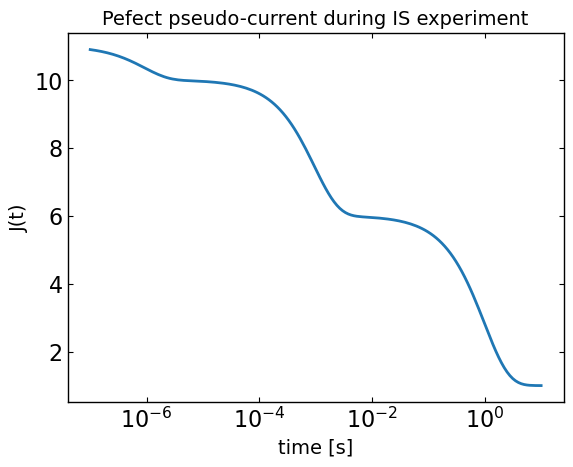

In [3]:
# Create a perfect curve using three lifetime values from time 
tau_perfect = [time[19], time[79], time[139]]
U_perfect = [1, 4, 5]
offset_perfect = 1

perfect_DRT_curve = drt.DRT_curve(time, U_perfect, tau_perfect, offset=offset_perfect)

# Plot the curve
plt.plot(time, perfect_DRT_curve, label='Perfect')
plt.title("Pefect pseudo-current during IS experiment")
plt.xlabel("time [s]")
plt.ylabel("J(t)")
plt.xscale('log')
plt.plot()

In [4]:
# Fit the data with no regularisation
U_scale_factor = perfect_DRT_curve.max() - perfect_DRT_curve.min()

# Remove offset till that is fixed in the code 
perfect_DRT_curve_scaled = perfect_DRT_curve - perfect_DRT_curve.min()

# fit the curve 
drt_linear = drt.fit_DRT_curve_linear_torch(time, perfect_DRT_curve, time, U_scale_factor=U_scale_factor, offset=0, alpha=0, max_iter=1000)

[]

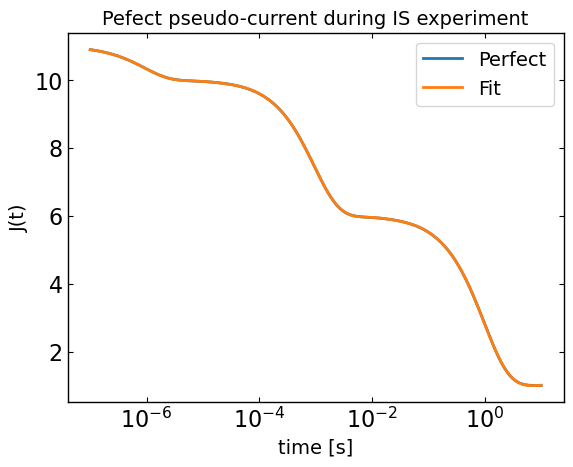

In [5]:
# Plot the curve
plt.plot(time, perfect_DRT_curve, label='Perfect')
plt.plot(time, drt_linear.DRT_curve, label='Fit')
plt.title("Pefect pseudo-current during IS experiment")
plt.xlabel("time [s]")
plt.ylabel("J(t)")
plt.xscale('log')
plt.legend()
plt.plot()

[]

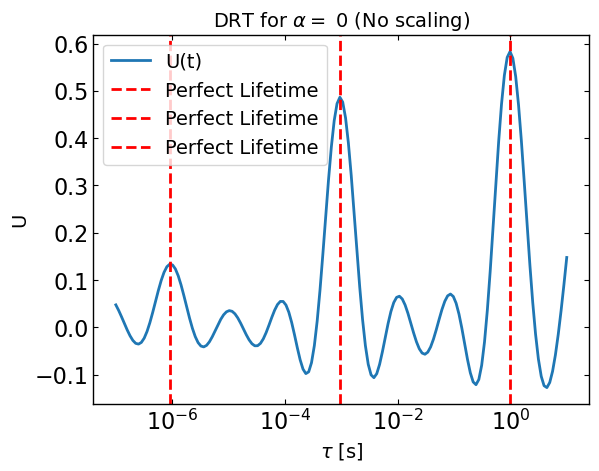

In [ ]:
plt.plot(time, drt_linear.U, label='U(t)')
for tau_value in tau_perfect:
    plt.axvline(tau_value, linestyle='--', color='red', label='Perfect Lifetime')
plt.title(f"DRT for $\\alpha =$ {0} (Offset Scaling)")
plt.xlabel("$\\tau$ [s]")
plt.ylabel("U")
plt.xscale('log')
plt.legend()
plt.plot()

In [10]:
# Try doing the same thing above for a range of alpha values
# Alpha value range 
alpha_values = np.geomspace(1e-3, 1e1, 10)
fits_linear_alpha = []

for alpha_value in alpha_values:
    drt_linear = drt.fit_DRT_curve_linear_torch(time, perfect_DRT_curve_scaled, time, U_scale_factor=U_scale_factor, offset=0, alpha=alpha_value, max_iter=1000)
    fits_linear_alpha.append(drt_linear)

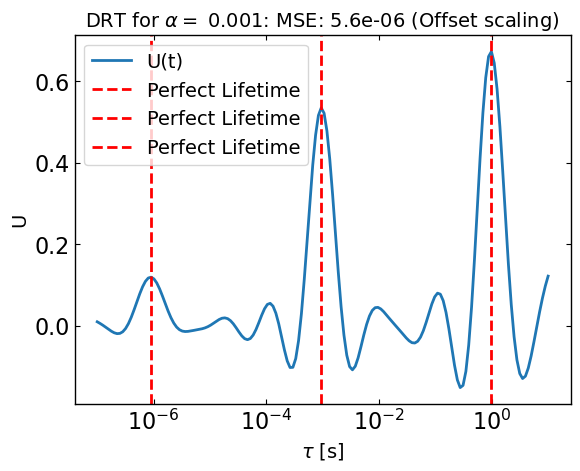

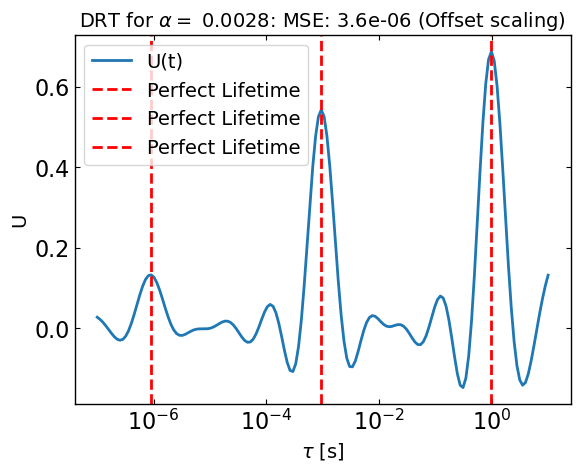

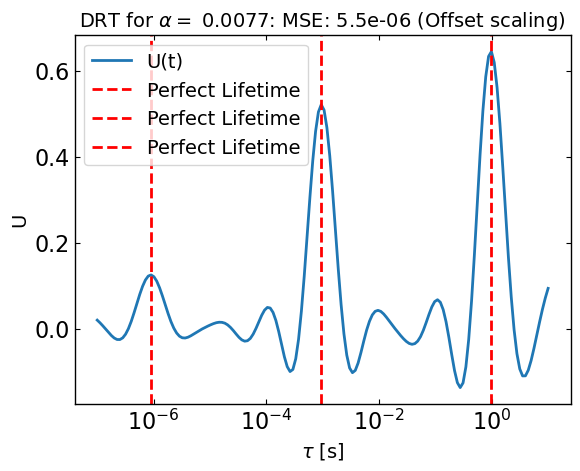

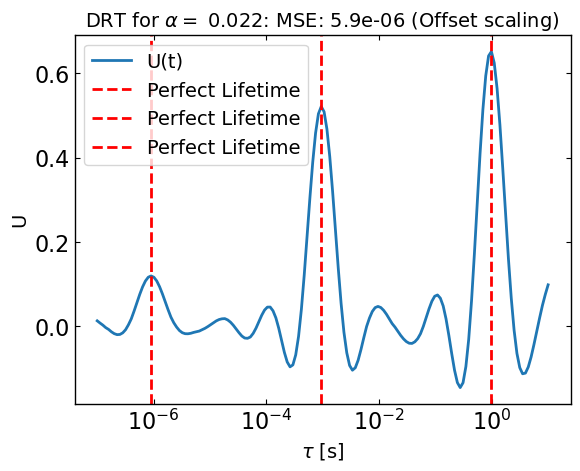

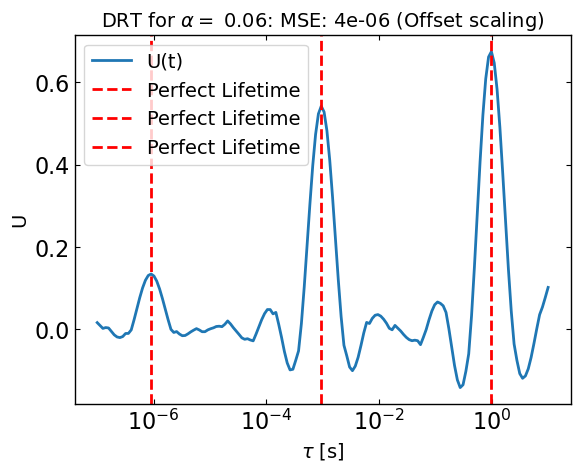

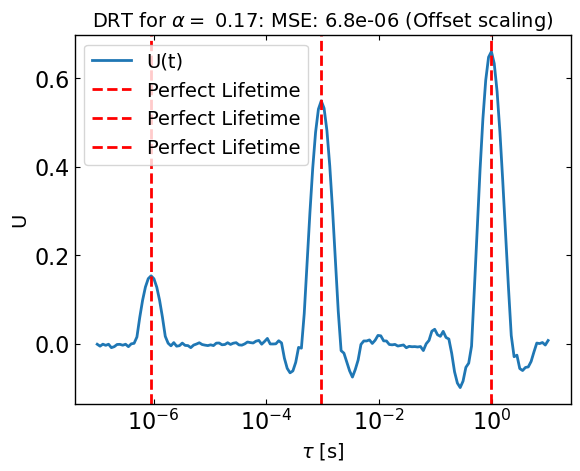

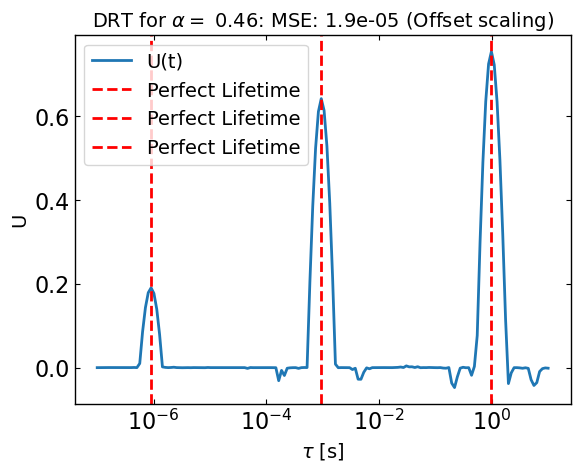

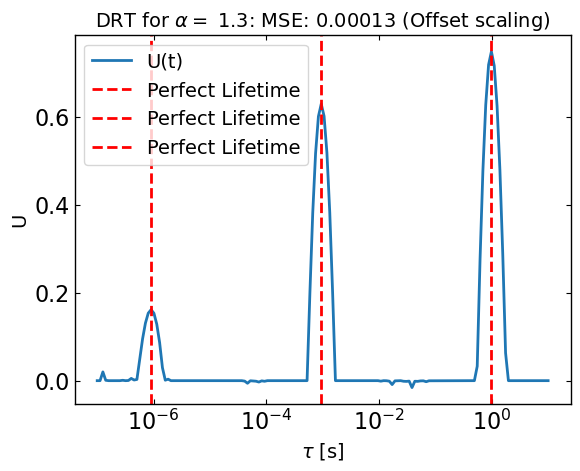

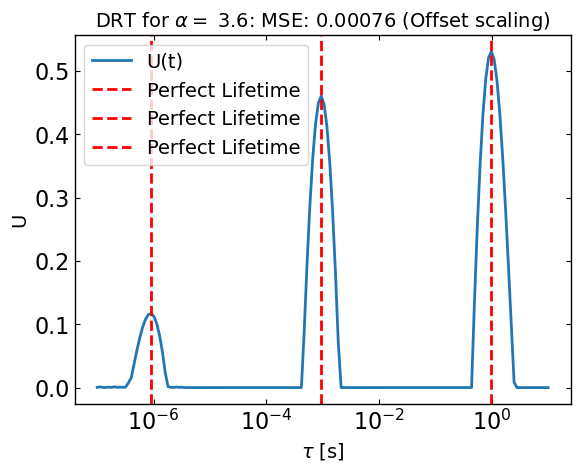

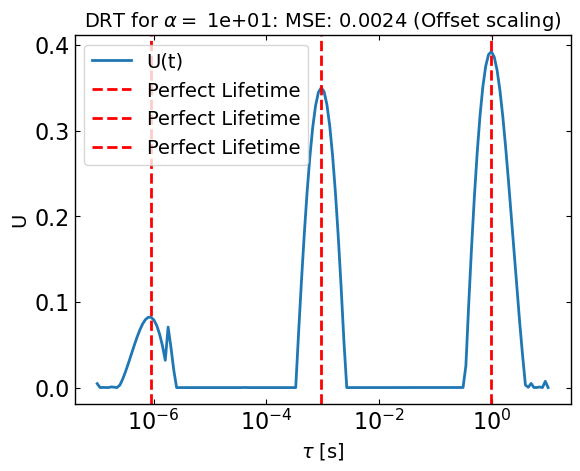

In [11]:
for i in range(len(fits_linear_alpha)):
    fit = fits_linear_alpha[i]
    MSE = np.mean((perfect_DRT_curve_scaled - fit.DRT_curve)**2)
    plt.plot(time, fit.U, label='U(t)')
    for tau_value in tau_perfect:
        plt.axvline(tau_value, linestyle='--', color='red', label='Perfect Lifetime')
    plt.title(f"DRT for $\\alpha =$ {alpha_values[i]:.2}: MSE: {MSE:.2} (Offset scaling)")
    plt.xlabel("$\\tau$ [s]")
    plt.ylabel("U")
    plt.xscale('log')
    plt.legend()
    plt.show()